In [1]:
# Cell 1: Import libraries
import nltk
import re
import difflib
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from nltk.corpus import brown, stopwords, words
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Cell 2: Download required NLTK resources
for resource in ["brown", "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "words"]:
    nltk.download(resource, quiet=True)

print("NLTK resources are ready.")


NLTK resources are ready.


In [3]:
# Cell 3: Load Brown Corpus and select 20 sentences
selected_sentences = [" ".join(s) for s in brown.sents()[:20]]

print("Number of selected sentences:", len(selected_sentences))
for i, s in enumerate(selected_sentences[:5], 1):
    print(f"{i}. {s}")


Number of selected sentences: 20
1. The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .
2. The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .
3. The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. .
4. `` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' .
5. The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous '' .


In [4]:
# Cell 4: Sentence and word tokenization
selected_text = " ".join(selected_sentences)
sentence_tokens = sent_tokenize(selected_text)
word_tokens_by_sentence = [word_tokenize(s) for s in sentence_tokens]

print("Sentence tokens:", len(sentence_tokens))
print("\nFirst 5 sentence tokens:")
for i, s in enumerate(sentence_tokens[:5], 1):
    print(f"{i}. {s}")

print("\nWord tokens from first sentence:")
print(word_tokens_by_sentence[0])


Sentence tokens: 19

First 5 sentence tokens:
1. The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .
2. The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .
3. The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. .
4. `` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' .
5. The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous 

In [5]:
# Cell 5: Lowercase + punctuation and stop-word removal
stop_words = set(stopwords.words("english"))
cleaned_tokens_by_sentence = []

for tokens in word_tokens_by_sentence:
    cleaned = [
        token.lower()
        for token in tokens
        if token.isalpha() and token.lower() not in stop_words
    ]
    cleaned_tokens_by_sentence.append(cleaned)

print("Cleaned tokens from first 5 sentences:")
for i, tokens in enumerate(cleaned_tokens_by_sentence[:5], 1):
    print(f"{i}. {tokens}")


Cleaned tokens from first 5 sentences:
1. ['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularities', 'took', 'place']
2. ['jury', 'said', 'presentments', 'city', 'executive', 'committee', 'charge', 'election', 'deserves', 'praise', 'thanks', 'city', 'atlanta', 'manner', 'election', 'conducted']
3. ['term', 'jury', 'charged', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'investigate', 'reports', 'possible', 'irregularities', 'primary', 'ivan', 'allen']
4. ['relative', 'handful', 'reports', 'received', 'jury', 'said', 'considering', 'widespread', 'interest', 'election', 'number', 'voters', 'size', 'city']
5. ['jury', 'said', 'find', 'many', 'georgia', 'registration', 'election', 'laws', 'outmoded', 'inadequate', 'often', 'ambiguous']


In [6]:
# Cell 6: Required Q1 output – original and cleaned tokens for 5 sentences
q1_df = pd.DataFrame({
    "Sentence": list(range(1, 6)),
    "Original Sentence": sentence_tokens[:5],
    "Original Word Tokens": [str(x) for x in word_tokens_by_sentence[:5]],
    "Cleaned Tokens": [str(x) for x in cleaned_tokens_by_sentence[:5]]
})
pd.set_option("display.max_colwidth", 250)
display(q1_df)


,Sentence,Original Sentence,Original Word Tokens,Cleaned Tokens
0,1,The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .,"['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', ""'s"", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``', 'that', 'any', 'irregularities', 'took', 'place', '.']","['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularities', 'took', 'place']"
1,2,"The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .","['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of...","['jury', 'said', 'presentments', 'city', 'executive', 'committee', 'charge', 'election', 'deserves', 'praise', 'thanks', 'city', 'atlanta', 'manner', 'election', 'conducted']"
2,3,The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. .,"['The', 'September-October', 'term', 'jury', 'had', 'been', 'charged', 'by', 'Fulton', 'Superior', 'Court', 'Judge', 'Durwood', 'Pye', 'to', 'investigate', 'reports', 'of', 'possible', '``', 'irregularities', '``', 'in', 'the', 'hard-fought', 'pr...","['term', 'jury', 'charged', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'investigate', 'reports', 'possible', 'irregularities', 'primary', 'ivan', 'allen']"
3,4,"`` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' .","['``', 'Only', 'a', 'relative', 'handful', 'of', 'such', 'reports', 'was', 'received', '``', ',', 'the', 'jury', 'said', ',', '``', 'considering', 'the', 'widespread', 'interest', 'in', 'the', 'election', ',', 'the', 'number', 'of', 'voters', 'an...","['relative', 'handful', 'reports', 'received', 'jury', 'said', 'considering', 'widespread', 'interest', 'election', 'number', 'voters', 'size', 'city']"
4,5,The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous '' .,"['The', 'jury', 'said', 'it', 'did', 'find', 'that', 'many', 'of', 'Georgia', ""'s"", 'registration', 'and', 'election', 'laws', '``', 'are', 'outmoded', 'or', 'inadequate', 'and', 'often', 'ambiguous', '``', '.']","['jury', 'said', 'find', 'many', 'georgia', 'registration', 'election', 'laws', 'outmoded', 'inadequate', 'often', 'ambiguous']"


In [7]:
# Cell 7: Extract 30+ alphabetic words
brown_words = [w.lower() for w in brown.words() if w.isalpha()]
required = ["playing", "studies", "running", "better", "cars"]
selected_words = list(dict.fromkeys(brown_words[:30] + required))

print("Number of selected words:", len(selected_words))
print(selected_words)


Number of selected words: 30
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', 'further', 'in', 'presentments', 'city', 'playing', 'studies', 'running', 'better', 'cars']


In [8]:
# Cell 8: Apply Porter Stemmer and WordNet Lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

q2_df = pd.DataFrame({
    "Original": selected_words,
    "Stemmed": [stemmer.stem(w) for w in selected_words],
    "Lemmatized": [lemmatizer.lemmatize(w) for w in selected_words]
})

display(q2_df)


,Original,Stemmed,Lemmatized
0,the,the,the
1,fulton,fulton,fulton
2,county,counti,county
3,grand,grand,grand
4,jury,juri,jury
5,said,said,said
6,friday,friday,friday
7,an,an,an
8,investigation,investig,investigation
9,of,of,of


In [9]:
# Cell 9: Explicit comparison of required examples
examples = ["playing", "studies", "running", "better", "cars"]

example_df = pd.DataFrame({
    "Original": examples,
    "Stemmed": [stemmer.stem(w) for w in examples],
    "Lemmatized": [lemmatizer.lemmatize(w) for w in examples]
})

display(example_df)


,Original,Stemmed,Lemmatized
0,playing,play,playing
1,studies,studi,study
2,running,run,running
3,better,better,better
4,cars,car,car


In [10]:
# Cell 10: Prepare NLTK Words Corpus vocabulary
vocabulary = set(w.lower() for w in words.words() if w.isalpha())

print("Vocabulary size:", len(vocabulary))


Vocabulary size: 234375


In [11]:
# Cell 11: At least 10 intentionally misspelled words
misspelled_words = [
    "recieve", "definately", "becuase", "seperate", "occured",
    "enviroment", "tommorow", "adress", "langauge", "studing",
    "acheive", "goverment"
]

print(misspelled_words)


['recieve', 'definately', 'becuase', 'seperate', 'occured', 'enviroment', 'tommorow', 'adress', 'langauge', 'studing', 'acheive', 'goverment']


In [12]:
# Cell 12: Approximate matching spelling correction
def correct_spelling(word, vocab, cutoff=0.6):
    word = word.lower()
    if word in vocab:
        return word
    matches = difflib.get_close_matches(word, vocab, n=1, cutoff=cutoff)
    return matches[0] if matches else "No suggestion"

q3_words_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Suggested Correction": [correct_spelling(w, vocabulary) for w in misspelled_words]
})

display(q3_words_df)


,Misspelled Word,Suggested Correction
0,recieve,reachieve
1,definately,definitely
2,becuase,bedcase
3,seperate,sperate
4,occured,occur
5,enviroment,environment
6,tommorow,tomorrow
7,adress,adpress
8,langauge,language
9,studing,studding


In [13]:
# Cell 13: Correct at least five example sentences
example_sentences = [
    "I definately want to recieve the certificate.",
    "The enviroment is important for every student.",
    "Please seperate the files by adress.",
    "I am studing natural langauge processing.",
    "The meeting occured becuase the teacher changed the schedule.",
    "I will complete the work tommorow."
]

def correct_sentence(sentence, vocab, cutoff=0.6):
    tokens = word_tokenize(sentence)
    corrected = []

    for token in tokens:
        if token.isalpha():
            word = correct_spelling(token, vocab, cutoff)
            if token[0].isupper() and word != "No suggestion":
                word = word.capitalize()
            corrected.append(word)
        else:
            corrected.append(token)

    result = " ".join(corrected)
    result = re.sub(r"\s+([,.!?;:])", r"\1", result)
    return result

q3_sentences_df = pd.DataFrame({
    "Original Sentence": example_sentences,
    "Corrected Sentence": [correct_sentence(s, vocabulary) for s in example_sentences]
})

display(q3_sentences_df)


,Original Sentence,Corrected Sentence
0,I definately want to recieve the certificate.,I definitely want to reachieve the certificate.
1,The enviroment is important for every student.,The environment is important for every student.
2,Please seperate the files by adress.,Please sperate the fils by adpress.
3,I am studing natural langauge processing.,I am studding natural language procession.
4,The meeting occured becuase the teacher changed the schedule.,The meeting occur bedcase the teacher change the schedule.
5,I will complete the work tommorow.,I will complete the work tomorrow.


In [14]:
# Cell 14: Prepare Brown Corpus subset
brown_subset = brown.words()[:20000]

ngram_tokens = [
    word.lower()
    for word in brown_subset
    if word.isalpha()
]

print("Number of preprocessed tokens:", len(ngram_tokens))
print("First 50 tokens:")
print(ngram_tokens[:50])


Number of preprocessed tokens: 17109
First 50 tokens:
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', 'the', 'jury', 'further', 'said', 'in', 'presentments', 'that', 'the', 'city', 'executive', 'committee', 'which', 'had', 'charge', 'of', 'the', 'election', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'city', 'of', 'atlanta', 'for', 'the']


In [15]:
# Cell 15: Generate N-grams
unigrams = list(ngrams(ngram_tokens, 1))
bigrams = list(ngrams(ngram_tokens, 2))
trigrams = list(ngrams(ngram_tokens, 3))

print("Unigrams:", len(unigrams))
print("Bigrams :", len(bigrams))
print("Trigrams:", len(trigrams))

print("\nFirst 10 unigrams:", unigrams[:10])
print("First 10 bigrams :", bigrams[:10])
print("First 10 trigrams:", trigrams[:10])


Unigrams: 17109
Bigrams : 17108
Trigrams: 17107

First 10 unigrams: [('the',), ('fulton',), ('county',), ('grand',), ('jury',), ('said',), ('friday',), ('an',), ('investigation',), ('of',)]
First 10 bigrams : [('the', 'fulton'), ('fulton', 'county'), ('county', 'grand'), ('grand', 'jury'), ('jury', 'said'), ('said', 'friday'), ('friday', 'an'), ('an', 'investigation'), ('investigation', 'of'), ('of', 'recent')]
First 10 trigrams: [('the', 'fulton', 'county'), ('fulton', 'county', 'grand'), ('county', 'grand', 'jury'), ('grand', 'jury', 'said'), ('jury', 'said', 'friday'), ('said', 'friday', 'an'), ('friday', 'an', 'investigation'), ('an', 'investigation', 'of'), ('investigation', 'of', 'recent'), ('of', 'recent', 'primary')]


In [16]:
# Cell 16: Calculate N-gram frequencies
unigram_freq = Counter(unigrams)
bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

print("Unique unigrams:", len(unigram_freq))
print("Unique bigrams :", len(bigram_freq))
print("Unique trigrams:", len(trigram_freq))


Unique unigrams: 3577
Unique bigrams : 12533
Unique trigrams: 16178


In [17]:
# Cell 17: Top 10 unigrams
top_unigrams = unigram_freq.most_common(10)
unigram_df = pd.DataFrame(
    [(g[0][0], f) for g, f in top_unigrams],
    columns=["Unigram", "Frequency"]
)
display(unigram_df)


,Unigram,Frequency
0,t,1436
1,o,622
2,t,497
3,a,405
4,i,399
5,a,342
6,f,239
7,t,191
8,i,158
9,h,158


In [18]:
# Cell 18: Top 10 bigrams
top_bigrams = bigram_freq.most_common(10)
bigram_df = pd.DataFrame(
    [(" ".join(g), f) for g, f in top_bigrams],
    columns=["Bigram", "Frequency"]
)
display(bigram_df)


,Bigram,Frequency
0,of the,207
1,in the,150
2,to the,66
3,on the,59
4,for the,58
5,that the,41
6,the state,39
7,would be,34
8,he said,34
9,and the,32


In [19]:
# Cell 19: Top 10 trigrams
top_trigrams = trigram_freq.most_common(10)
trigram_df = pd.DataFrame(
    [(" ".join(g), f) for g, f in top_trigrams],
    columns=["Trigram", "Frequency"]
)
display(trigram_df)


,Trigram,Frequency
0,the united states,15
1,one of the,9
2,is expected to,9
3,in the state,8
4,some of the,8
5,the jury said,7
6,chairman of the,7
7,session of the,7
8,president of the,7
9,of the ward,6


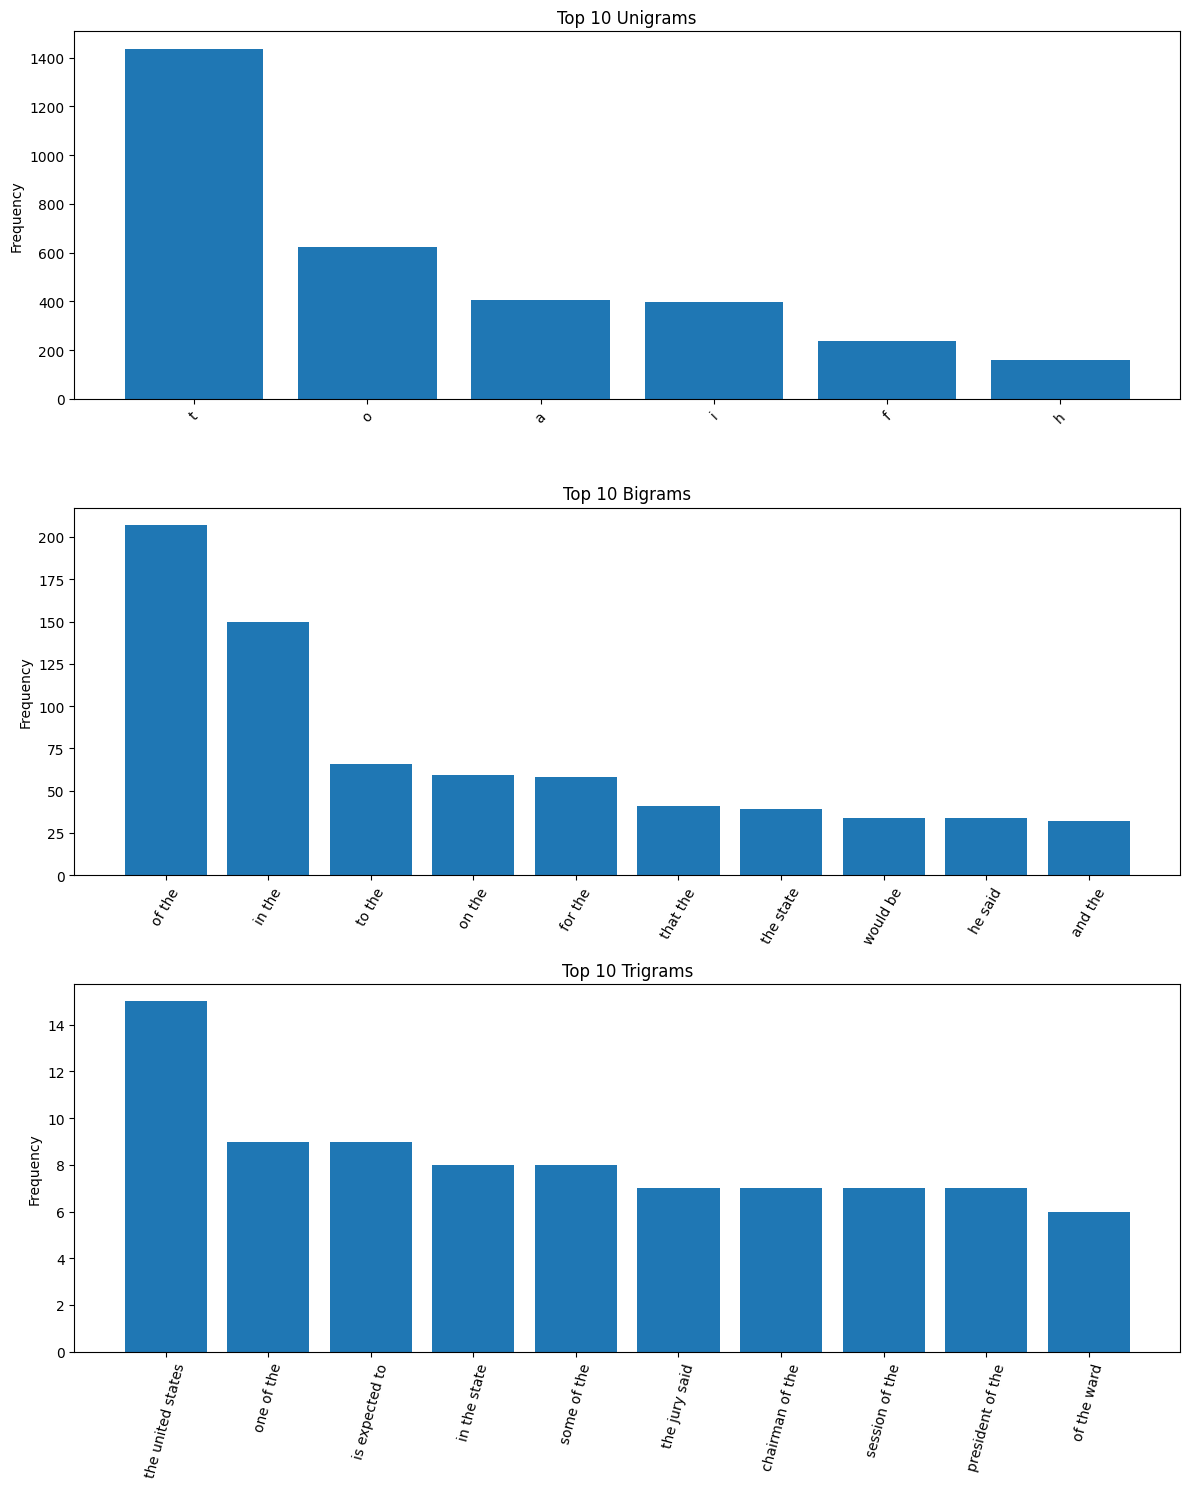

In [20]:
# Cell 20: Visualize top 10 N-grams
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].bar(
    [g[0][0] for g, f in top_unigrams],
    [f for g, f in top_unigrams]
)
axes[0].set_title("Top 10 Unigrams")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    [" ".join(g) for g, f in top_bigrams],
    [f for g, f in top_bigrams]
)
axes[1].set_title("Top 10 Bigrams")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis="x", rotation=60)

axes[2].bar(
    [" ".join(g) for g, f in top_trigrams],
    [f for g, f in top_trigrams]
)
axes[2].set_title("Top 10 Trigrams")
axes[2].set_ylabel("Frequency")
axes[2].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()
